In [ ]:
# Install packages + Load Boston dataset
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
np.random.seed(500)
torch.manual_seed(500)
# Load Boston dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)
data = boston.frame
# Rename target column
data = data.rename(columns={"MEDV": "medv"})
# Convert all columns to numeric
data = data.apply(pd.to_numeric)
print(data.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  medv  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [ ]:
print(data.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
medv       0
dtype: int64


In [ ]:
X = data.drop("medv", axis=1)
y = data["medv"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=500)
lm_fit = LinearRegression()
lm_fit.fit(X_train, y_train)

LinearRegression()

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y_scaled, train_size=0.75, random_state=500)

In [ ]:
X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_s, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_s, dtype=torch.float32)
model = nn.Sequential(nn.Linear(13, 5),nn.ReLU(),nn.Linear(5, 3),
nn.ReLU(),nn.Linear(3, 1))
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

Sequential(
  (0): Linear(in_features=13, out_features=5, bias=True)
  (1): ReLU()
  (2): Linear(in_features=5, out_features=3, bias=True)
  (3): ReLU()
  (4): Linear(in_features=3, out_features=1, bias=True)
)


In [ ]:
epochs = 1000
for epoch in range(epochs):
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 100, Loss: 0.0328
Epoch 200, Loss: 0.0193
Epoch 300, Loss: 0.0128
Epoch 400, Loss: 0.0086
Epoch 500, Loss: 0.0076
Epoch 600, Loss: 0.0074
Epoch 700, Loss: 0.0073
Epoch 800, Loss: 0.0072
Epoch 900, Loss: 0.0072
Epoch 1000, Loss: 0.0072


In [ ]:
with torch.no_grad():
 pr_nn_scaled = model(X_test_tensor).numpy()
pr_nn = scaler_y.inverse_transform(pr_nn_scaled)
test_r = scaler_y.inverse_transform(y_test_tensor.numpy())
MSE_nn = mean_squared_error(test_r, pr_nn)
print("Neural Network MSE:", MSE_nn)

Neural Network MSE: 33.63422775268555


In [ ]:
predictions_lm = lm_fit.predict(X_test)
MSE_lm = mean_squared_error(y_test, predictions_lm)
print("Linear Regression MSE:", MSE_lm)
print("Neural Network MSE:", MSE_nn)

Linear Regression MSE: 36.56457544041186
Neural Network MSE: 33.63422775268555


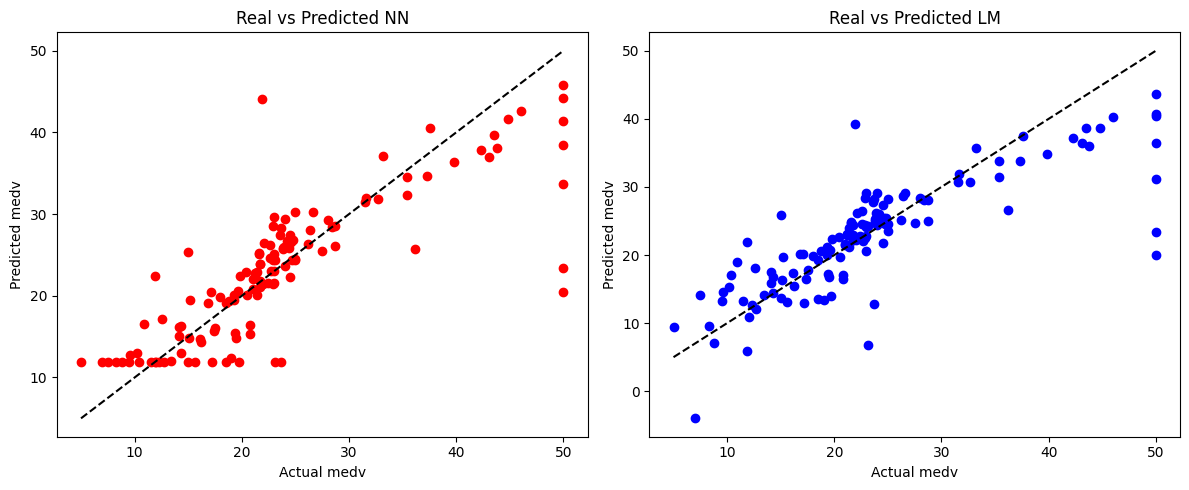

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(test_r, pr_nn, color="red", marker="o")
plt.plot([test_r.min(), test_r.max()],[test_r.min(), test_r.max()],"k--")
plt.xlabel("Actual medv")
plt.ylabel("Predicted medv")
plt.title("Real vs Predicted NN")
plt.subplot(1, 2, 2)
plt.scatter(y_test, predictions_lm, color="blue", marker="o")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],"k--")
plt.xlabel("Actual medv")
plt.ylabel("Predicted medv")
plt.title("Real vs Predicted LM")
plt.tight_layout()
plt.show()

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

In [ ]:
def initialize_parameters(layer_dims):
    np.random.seed(42)
    parameters = {}

    for l in range(1, len(layer_dims)):
        parameters[f"W{l}"] = np.random.randn(layer_dims[l], layer_dims[l-1]) * 0.1
        parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))

    return parameters

In [ ]:
def forward_propagation(X, parameters):
    cache = {"A0": X}
    L = len(parameters) // 2

    for l in range(1, L + 1):
        W = parameters[f"W{l}"]
        b = parameters[f"b{l}"]
        A_prev = cache[f"A{l-1}"]

        Z = np.dot(W, A_prev) + b
        A = sigmoid(Z)

        cache[f"Z{l}"] = Z
        cache[f"A{l}"] = A

    return A, cache

In [ ]:
def compute_mse(Y, Y_hat):
    return np.mean((Y - Y_hat) ** 2)